# Preprocessing
## Metadata Preprocessing

In [7]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

In [8]:
import pandas as pd

dataset_path = "/Volumes/Secretary/Datasets/NIH_Chest_X-Rays"
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")

df = pd.read_csv(metadata_file)

print(df.head())
print("Total images:", len(df))
print("Unique patients:", df["Patient ID"].nunique())

Dataset location: /Volumes/Secretary/Datasets/NIH_Chest_X-Rays
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   
3  00000002_000.png              No Finding            0           2   
4  00000003_000.png                  Hernia            0           3   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   
3           81              M            PA                 2500     2048   
4           81              F            PA                 2582     2991   

   OriginalImagePixelSpacing[x     y]  Un

In [9]:
df["Finding Labels"].value_counts().head()

Finding Labels
No Finding      60361
Infiltration     9547
Atelectasis      4215
Effusion         3955
Nodule           2705
Name: count, dtype: int64

In [10]:
df["target"] = (df["Finding Labels"] != "No Finding").astype(int)
proportions = df["target"].value_counts(normalize=True)
print(proportions)

target
0    0.538361
1    0.461639
Name: proportion, dtype: float64


In [11]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,target
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,1
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,1
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,1
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,0
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,1


In [12]:
import numpy as np

patients = df["Patient ID"].unique()  
# Returns array of unique patient IDs from the dataframe

rng = np.random.default_rng(42)
rng.shuffle(patients)
# Shuffles temp dataframe of patients in random order, with a fixed seed for reproducibility

n = len(patients)
train_ids = set(patients[:int(0.7 * n)])
val_ids = set(patients[int(0.7 * n):int(0.85 * n)])
test_ids = set(patients[int(0.85):])
# Generates and identifies set proportions by patient IDs (70% train, 15% val, 15% test)

def assign_split(pid):
    if pid in train_ids:
        return "train"
    elif pid in val_ids:
        return "val"
    return "test"
# Function to assign set splits by patient ID

df["split"] = df["Patient ID"].apply(assign_split)
# Assigns split labels (new column) to the actual dataframe based on patient ID

df["split"].value_counts()
print(df.groupby("split")["target"].value_counts(normalize=True))

split  target
test   0         0.537948
       1         0.462052
train  0         0.537259
       1         0.462741
val    0         0.543914
       1         0.456086
Name: proportion, dtype: float64


# Image Preprocessing

In [13]:
from pathlib import Path
image_root = Path(dataset_path)
all_images = list(image_root.rglob("*.png"))
# List of all image file paths

image_map = {p.name: str(p) for p in all_images}
# Maps image file names to their full paths

df["image_path"] = df["Image Index"].map(image_map)
# Adds a new column with the full image paths

missing = df["image_path"].isna().sum()
print("Missing image paths:", missing)

Missing image paths: 0


In [14]:
from PIL import Image

sample_paths = df["image_path"].dropna().sample(200, random_state=42)

sizes = []
modes = []
bad_files = []

for path in sample_paths:
    try:
        img = Image.open(path)
        sizes.append(img.size)
        modes.append(img.mode)
    except Exception:
        bad_files.append(path)

print("Unique modes:", set(modes))
print("Example sizes:", sizes[:10])
print("Unreadable files:", len(bad_files))

Unique modes: {'L', 'RGBA'}
Example sizes: [(1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024), (1024, 1024)]
Unreadable files: 0


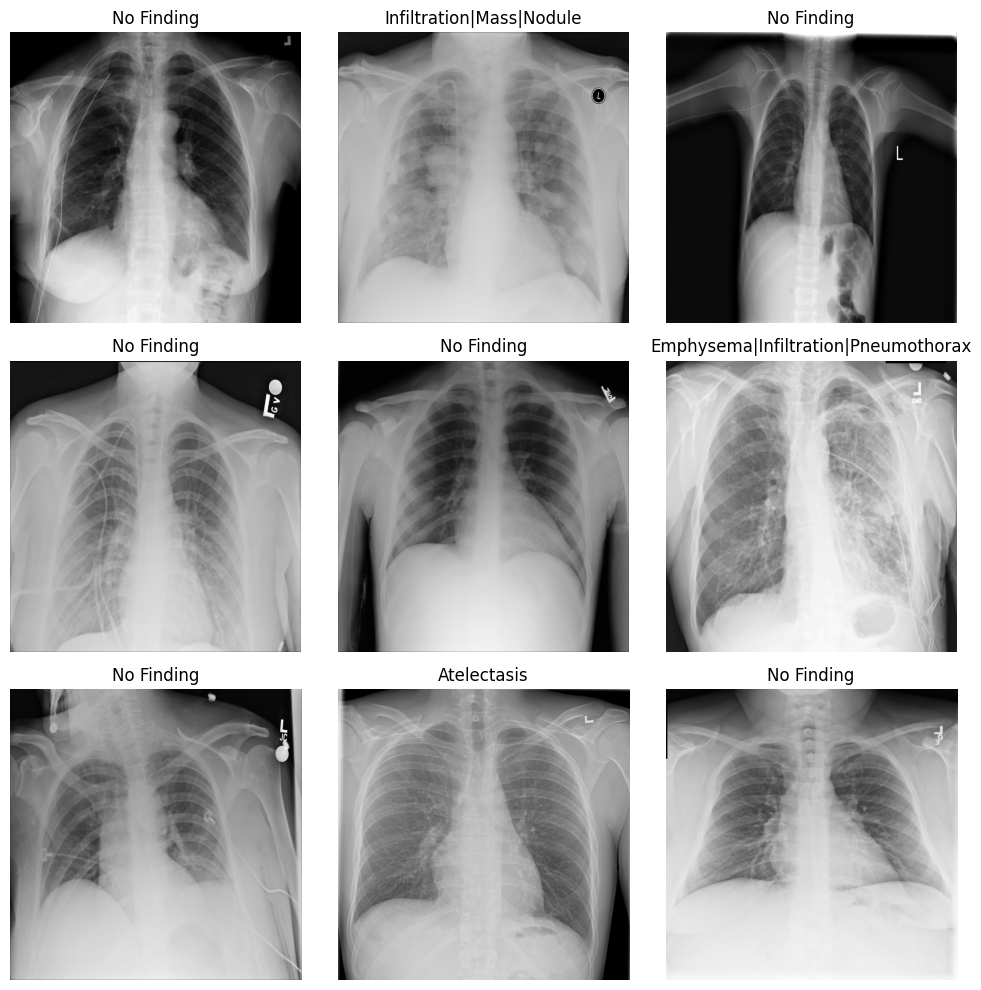

In [15]:
import matplotlib.pyplot as plt

sample_df = df.sample(9, random_state = 42)

fig, axes, = plt.subplots(3, 3, figsize = (10, 10))

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = Image.open(row["image_path"]).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(row["Finding Labels"])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training Preprocessing

In [16]:
import data

train_transforms, eval_transforms = data.get_transforms()

train_data, val_data, test_data = data.split_dataframe(df)
train_ds, val_ds, test_ds = data.create_datasets(train_data, val_data, test_data, train_transforms, eval_transforms)
train_loader, val_loader, test_loader = data.create_dataloaders(train_ds, val_ds, test_ds)

In [17]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
# Get a single batch from the training dataloader and print out the shapes and data types of the images and labels to verify everything is working correctly

Image batch shape: torch.Size([32, 1, 224, 224])
Label batch shape: torch.Size([32])
Image dtype: torch.float32
Label dtype: torch.int64


# Baseline CNN

In [18]:
from utils import get_device
from models import SimpleCNN
from train_eval import setup_training
import config

device = get_device()

model = SimpleCNN().to(device)

criterion, optimizer = setup_training(model, lr=config.LEARNING_RATE)

Using MPS (GPU)


## Training

In [ ]:
from train_eval import train_model

history = train_model(model, train_loader, val_loader, criterion, optimizer, device, "simple_cnn_binary_target")

Train Epoch 1:   0%|          | 0/2467 [00:00<?, ?it/s]

Train Epoch 1:   1%|          | 24/2467 [00:23<46:37,  1.15s/it, avg_acc=0.5612, avg_loss=0.7091, batch_loss=0.7088]

KeyboardInterrupt: 

## Training History

(<Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>,
 <Figure size 800x500 with 1 Axes>)

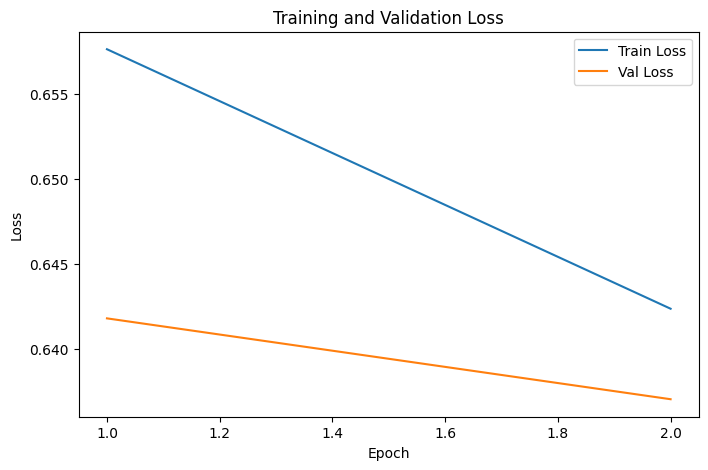

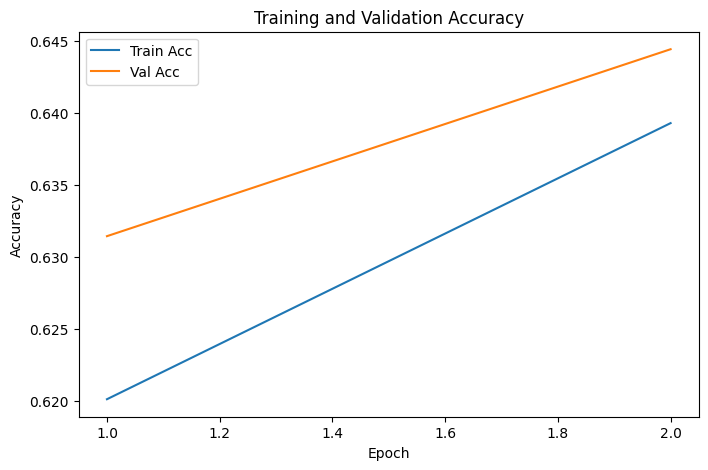

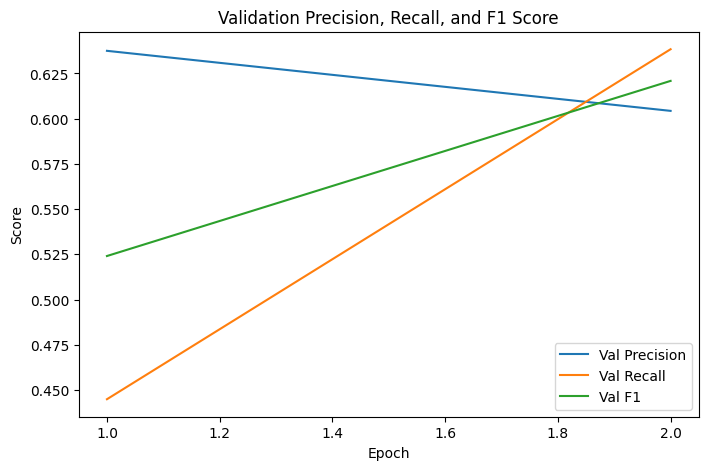

In [ ]:
from utils import plot_training_history

plot_training_history(history)

# Testing Best Model

In [19]:
import torch
from utils import get_model_path
from train_eval import evaluate
import config

save_path = get_model_path("best_simple_cnn")
print(save_path)
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model = SimpleCNN().to(device)
best_model.load_state_dict(torch.load(save_path, map_location=device))

test_loss, test_acc, test_precision, test_recall, test_f1, test_labels, test_preds = evaluate(
    best_model, test_loader, criterion, device
)

print("Test Results")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1 Score: {test_f1:.4f}")

/Users/tommy_tran/cxr-ai/saved_models/best_simple_cnn.pt


Test Results
  Loss: 0.6337
  Accuracy: 0.6480
  Precision: 0.6162
  Recall: 0.6313
  F1 Score: 0.6237


## Evaluating Test Results

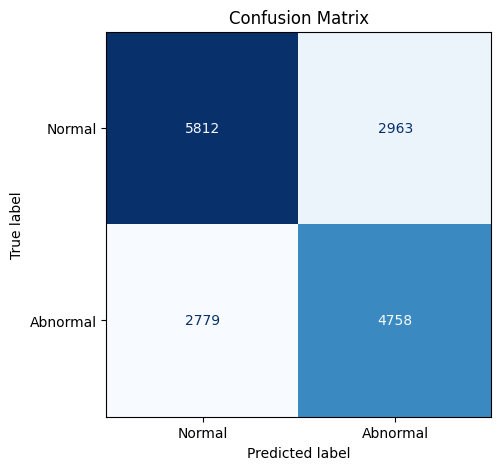

In [20]:
from utils import plot_confusion_matrix_figure

plot_confusion_matrix_figure(test_labels, test_preds, ["Normal", "Abnormal"])

## Making Prediction

In [36]:
from train_eval import predict_single_image

sample_row = test_data.sample(1, random_state=42).iloc[0]
result = predict_single_image(sample_row["image_path"], best_model, device, eval_transforms) 

print("True label:", sample_row["target"])
print("Predicted label:", sample_row["Finding Labels"])
print("Predcition:", result)

True label: 0
Predicted label: No Finding
Predcition: {'predicted_class': 'abnormal', 'probabilities': {'normal': 0.3861806094646454, 'abnormal': 0.6138193607330322}}
